# Example: Self-Attention for Sentiment Classification
This example replaces the mean-pooled bag-of-embeddings classifier from the [L10b lab](https://github.com/varnerlab/CHEME-5820-Labs-Spring-2026) with a single self-attention layer over the same QuantumBrew product reviews. The goal is to make the difference between bag-of-embeddings and self-attention concrete on a task where we already know the baseline fails on negation and sarcasm.

> __Learning Objectives:__
>
> By the end of this example, you should be able to:
>
> * __Apply scaled dot-product self-attention to a classification task:__ Build, train, and evaluate a single-head self-attention classifier on padded token-vector sequences, using GloVe embeddings as the input representation.
> * __Compare self-attention against a mean-pool baseline on the same data:__ Train both architectures on the same train/test split and interpret the difference in test accuracy and confusion-matrix structure.
> * __Read attention weights as a model-interpretation tool:__ Plot the attention matrix for a single review and identify which tokens the model attends to when classifying adversarial examples.

Let's get started!
___

## Setup, Data, and Prerequisites
We set up the computational environment by including the `Include.jl` file, loading any needed resources, such as sample datasets, and setting up any required constants.

> The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, and includes local source files in `src/`. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/).

In [1]:
include(joinpath(@__DIR__, "Include.jl")); # include the Include.jl file

  Activating project at `~/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CHEME-5820-Lectures-Spring-2026/lectures/week-13/L13a`


In addition to standard Julia libraries, we'll also use [the `VLDataScienceMachineLearningPackage.jl` package](https://github.com/varnerlab/VLDataScienceMachineLearningPackage.jl). Check out [the documentation](https://varnerlab.github.io/VLDataScienceMachineLearningPackage.jl/dev/) for more information on the functions, types, and data used in this material.

### Data
We use the same Stanford GloVe 6B 100-dimensional vectors and the same `generate_quantumbrew_reviews()` function as the L10b lab, so that the comparison between the two architectures is on identical data. Let's load the GloVe vectors and generate the QuantumBrew reviews.

In [2]:
# check: do we have a local copy of the GloVe embeddings? If not, download them.
glove_path = joinpath(_PATH_TO_DATA, "glove.6B.100d.txt");
isfile(glove_path) || (glove_path = download_glove(_PATH_TO_DATA; dim=100));
glove = load_glove_embeddings(glove_path); # load the GloVe vectors into a Dict{String, Vector{Float32}}
@info "GloVe loaded" n_words=length(glove);

┌ Info: GloVe loaded
│   n_words = 400000
└ @ Main /Users/jeffreyvarner/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CHEME-5820-Lectures-Spring-2026/lectures/week-13/L13a/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y101sZmlsZQ==.jl:5


In [3]:
# generate the synthetic QuantumBrew reviews dataset (positive, negative, neutral + adversarial)
reviews_df = generate_quantumbrew_reviews();
@info "Reviews generated" n=nrow(reviews_df);
class_counts = combine(groupby(reviews_df, :label), nrow => :count); # count reviews per class
pretty_table(class_counts)

┌ Info: Reviews generated
│   n = 999
└ @ Main /Users/jeffreyvarner/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CHEME-5820-Lectures-Spring-2026/lectures/week-13/L13a/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y102sZmlsZQ==.jl:3


┌──────────┬───────┐
│    label │ count │
│   String │ Int64 │
├──────────┼───────┤
│  neutral │   333 │
│ positive │   333 │
│ negative │   333 │
└──────────┴───────┘


### Implementations
We use helper functions defined in this notebook:

| Function | Description |
| --- | --- |
| `confusion_matrix(...)` | Build a confusion matrix from true and predicted label indices |
| `plot_attention(...)` | Extract attention weights from a trained model and render as a heatmap over valid tokens |
| `_negation_count(...)` | Count negation-related tokens in a review string |

In [4]:
"""Build a confusion matrix C where C[t, p] counts how many times true class t was predicted as class p."""
function confusion_matrix(y_true_idx::Vector{Int}, y_pred_idx::Vector{Int}, n_classes::Int)
    C = zeros(Int, n_classes, n_classes); # initialize n_classes × n_classes matrix of zeros
    for (t, p) in zip(y_true_idx, y_pred_idx)
        C[t, p] += 1; # increment the count for (true class t, predicted class p)
    end
    return C;
end

confusion_matrix

Next, we define the attention visualization function.

In [5]:
"""Extract the attention weight matrix from a trained model and render it as a heatmap."""
function plot_attention(model::AttentionClassifier, X_one::AbstractArray{<:Real, 3},
                          mask_one::AbstractMatrix{Bool}, tokens_one::Vector{String};
                          title_str::String="attention")

    w = attention_weights(model, X_one, mask_one);              # (n, n, 1) attention weight tensor
    n_valid = sum(mask_one);                                     # number of real (non-padding) tokens
    A = collect(Float64.(w[1:n_valid, 1:n_valid, 1]));          # extract the valid region as a dense matrix
    toks = tokens_one[1:n_valid];                                # token strings for axis labels

    # plot: use integer axes with manual tick labels to avoid Plots.jl sorting strings alphabetically
    heatmap(1:n_valid, 1:n_valid, A;
            xticks=(1:n_valid, toks), yticks=(1:n_valid, toks),
            xlabel="key (attended-to token)",
            ylabel="query (attending token)",
            title=title_str,
            xrotation=60, color=:viridis,
            size=(700, 600), yflip=true)
end

plot_attention

Finally, we define a helper to count negation tokens in a review.

In [6]:
"""Count negation-related tokens in a review string (used to identify double-negative reviews)."""
function _negation_count(text::String)
    s = lowercase(text);
    return count(" not ", s) + count(" never ", s) + count(" no ", s) +
           count(" without ", s) + count("disappoint", s) + count("worst", s) +
           count("terrible", s) + count("bad", s)
end

_negation_count

### Constants
We define constants used throughout the example. The embedding dimension `D_EMB` matches the GloVe vector size, and the maximum sequence length `N_MAX` controls padding and truncation of reviews. The class names `CLASS_NAMES` and class count `N_CLASSES` are defined in the label-encoding cell below.

In [7]:
const D_EMB = 100;  # GloVe embedding dimension
const N_MAX = 32;   # max sequence length (pad or truncate each review to this length)

# embed each review as a padded sequence of GloVe vectors: X_seq is (d, n_max, N), mask is (n_max, N)
X_seq, mask, tokens_str = embed_reviews_sequence(string.(reviews_df.review), glove;
                                                  dim=D_EMB, n_max=N_MAX);
@info "Padded sequences" X_shape=size(X_seq) mask_shape=size(mask) avg_valid=round(mean(sum(mask; dims=1)), digits=2) max_valid=maximum(sum(mask; dims=1))

┌ Info: Padded sequences
│   X_shape = (100, 32, 999)
│   mask_shape = (32, 999)
│   avg_valid = 27.38
│   max_valid = 32
└ @ Main /Users/jeffreyvarner/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CHEME-5820-Lectures-Spring-2026/lectures/week-13/L13a/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y113sZmlsZQ==.jl:7


The padded sequences are stored in `X_seq` (a `d × n_max × N` tensor of GloVe vectors), the boolean padding mask in `mask` (`n_max × N`), and the per-review token strings in `tokens_str`.

Next, we encode the three labels (positive / negative / neutral) as integer indices and one-hot vectors. The label mapping is stored in `label_to_idx`, the integer labels in `y_idx`, and the one-hot matrix in `y_onehot`.

In [8]:
const CLASS_NAMES = ["positive", "negative", "neutral"];
const N_CLASSES = length(CLASS_NAMES);

label_to_idx = Dict(c => i for (i, c) in enumerate(CLASS_NAMES)); # map class name → integer index
y_idx = [label_to_idx[l] for l in reviews_df.label];              # integer labels for all reviews
y_onehot = Float32.(Flux.onehotbatch(y_idx, 1:N_CLASSES));        # one-hot encode for cross-entropy loss

We then take an 80/20 train/test split. The training and test tensors are stored in `X_train_seq`, `mask_train`, `y_train` and `X_test_seq`, `mask_test`, `y_test`. The index arrays `TRAIN_IDX` and `TEST_IDX` are saved globally for use by the baseline model.

In [9]:
X_train_seq, mask_train, y_train, X_test_seq, mask_test, y_test, TRAIN_IDX, TEST_IDX = let

    # shuffle and split into 80% train / 20% test
    Random.seed!(42);
    N = size(X_seq, 3);             # total number of reviews
    perm = randperm(N);             # random permutation of review indices
    n_train = round(Int, 0.8 * N); # number of training reviews
    train_idx = perm[1:n_train];       # training indices (used later for baseline)
    test_idx  = perm[n_train+1:end];   # test indices (used later for baseline)

    # slice the sequence tensors, masks, and labels by train/test indices
    X_train_seq, mask_train, y_train = X_seq[:, :, train_idx], mask[:, train_idx], y_onehot[:, train_idx];
    X_test_seq,  mask_test,  y_test  = X_seq[:, :, test_idx],  mask[:, test_idx],  y_onehot[:, test_idx];
    @info "split" n_train=size(X_train_seq, 3) n_test=size(X_test_seq, 3)

    # return -
    (X_train_seq, mask_train, y_train, X_test_seq, mask_test, y_test, train_idx, test_idx)
end

┌ Info: split
│   n_train = 799
│   n_test = 200
└ @ Main /Users/jeffreyvarner/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CHEME-5820-Lectures-Spring-2026/lectures/week-13/L13a/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y121sZmlsZQ==.jl:14


(Float32[-0.57058 0.13717 … 0.0 0.0; 0.44183 -0.54287 … 0.0 0.0; … ; 0.47197 0.25434 … 0.0 0.0; 0.37253 -0.23759 … 0.0 0.0;;; -0.046539 0.13717 … 0.0 0.0; 0.61966 -0.54287 … 0.0 0.0; … ; -0.032502 0.25434 … 0.0 0.0; 0.8062 -0.23759 … 0.0 0.0;;; -0.54264 -0.02193 … -0.14166 0.014314; 0.41476 0.36404 … 0.62942 0.68838; … ; 0.76217 0.015174 … 0.44719 0.79593; 0.46349 0.33517 … 0.2194 -0.30368;;; … ;;; -0.046539 0.40532 … 0.0 0.0; 0.61966 -0.10608 … 0.0 0.0; … ; -0.032502 0.10536 … 0.0 0.0; 0.8062 0.30057 … 0.0 0.0;;; -0.54264 0.44411 … 0.0 0.0; 0.41476 0.43398 … 0.0 0.0; … ; 0.76217 0.46756 … 0.0 0.0; 0.46349 0.25779 … 0.0 0.0;;; -0.54264 -0.22557 … 0.0 0.0; 0.41476 0.49418 … 0.0 0.0; … ; 0.76217 0.49646 … 0.0 0.0; 0.46349 0.34906 … 0.0 0.0], Bool[1 1 … 1 1; 1 1 … 1 1; … ; 0 0 … 0 0; 0 0 … 0 0], Float32[0.0 0.0 … 1.0 0.0; 1.0 1.0 … 0.0 1.0; 0.0 0.0 … 0.0 0.0], Float32[-0.046539 0.63256 … 0.0 0.0; 0.61966 -0.12718 … 0.0 0.0; … ; -0.032502 0.22378 … 0.0 0.0; 0.8062 0.038183 … 0.0 0.0;;; -0.

___

## Task 1: Build the Self-Attention Classifier
The model is built from three pieces, all defined in [src/Attention.jl](src/Attention.jl).

> __Architecture__
>
> * __SelfAttention layer__: a single head of scaled dot-product self-attention with learnable projections $\mathbf{W}_{Q}, \mathbf{W}_{K}\in\mathbb{R}^{d\times d_{k}}$ and $\mathbf{W}_{V}\in\mathbb{R}^{d\times d_{v}}$. Implements $\operatorname{Attention}(\mathbf{Q},\mathbf{K},\mathbf{V}) = \operatorname{softmax}(\mathbf{Q}\mathbf{K}^{\top}/\sqrt{d_{k}})\mathbf{V}$ exactly as defined in the L13a lecture, with padding positions masked to large negative scores so they receive zero attention weight.
> * __Masked mean-pool__: averages the attention output over valid sequence positions only, producing a single vector per review.
> * __MLP head__: a two-layer feedforward network `Dense(d_v → d_hidden, relu) → Dense(d_hidden → 3)` that maps the pooled vector to class logits.

We use $d_{k} = d_{v} = 32$ (so the projections compress the $100$-dimensional GloVe vectors), and a hidden dimension of $64$ in the MLP head. The model is stored in `model` (an `AttentionClassifier` instance) and the total number of trainable parameters in `n_params`.

In [10]:
model, n_params, D_HIDDEN = let

    # initialize - set the projection and hidden dimensions
    d_k = 32;           # query/key projection dimension
    d_v = 32;           # value projection dimension
    d_hidden = 64;      # MLP hidden layer width (used later for baseline)

    # build the self-attention classifier: SelfAttention → mean-pool → MLP head
    Random.seed!(42);
    model = AttentionClassifier(D_EMB, d_k, d_v, d_hidden, N_CLASSES);
    n_params = sum(length, Flux.trainables(model)); # count total trainable parameters
    @info "self-attention classifier" n_params=n_params d_emb=D_EMB d_k=d_k d_v=d_v d_hidden=d_hidden

    # return -
    (model, n_params, d_hidden)
end

┌ Info: self-attention classifier
│   n_params = 11907
│   d_emb = 100
│   d_k = 32
│   d_v = 32
│   d_hidden = 64
└ @ Main /Users/jeffreyvarner/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CHEME-5820-Lectures-Spring-2026/lectures/week-13/L13a/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y124sZmlsZQ==.jl:12


(AttentionClassifier(SelfAttention(Float32[0.07883556 -0.06705636 … 0.0091953045 0.044905484; -0.087985866 0.07137771 … -0.24521525 -0.02489299; … ; 0.22573511 0.11661624 … -0.04915826 -0.0034994788; 0.050030667 -0.067069866 … 0.04602074 -0.05519716], Float32[-0.025188966 -0.014465715 … 0.02446946 0.009250629; -0.029404411 0.080438025 … 0.04099404 -0.011656693; … ; 0.053940773 -0.10859766 … -0.14535925 -0.08941074; -0.062205117 -0.0070551224 … 0.08234948 0.10843158], Float32[0.14323889 0.06820453 … -0.011581373 -0.044493552; 0.032520648 0.13165283 … -0.06901025 -0.012700796; … ; -0.030718654 0.11564889 … 0.19167386 -0.14337917; -0.08884467 -0.04902923 … 0.07333143 -0.05040273]), Chain(Dense(32 => 64, relu), Dense(64 => 3))), 11907, 64)

___

## Task 2: Train the Self-Attention Classifier
We train with Adam at learning rate $3\times 10^{-3}$ for $30$ epochs at batch size $32$. The first run trains and saves a checkpoint to `data/attention_sentiment_H64.jld2`; subsequent runs detect the checkpoint and load it instead of retraining.

> __Note__: The training cell checks for a saved checkpoint before training. If a checkpoint exists, the model weights are loaded directly. Otherwise, the model is trained from scratch and the checkpoint is saved for future runs.

In [11]:
train_loss_history = let

    # initialize -
    checkpoint_path = joinpath(_PATH_TO_DATA, "attention_sentiment_H64.jld2");
    n_epochs = 30;       # number of training epochs
    batchsize = 32;      # mini-batch size for SGD
    train_loss_history = Float32[];

    if isfile(checkpoint_path)
        # checkpoint exists: load saved model weights and loss history instead of retraining
        @info "Loading pre-trained checkpoint" path=checkpoint_path
        saved = JLD2.load(checkpoint_path);
        Flux.loadmodel!(model, saved["model_state"]);
        train_loss_history = saved["train_loss_history"];
        @info "Loaded model from checkpoint"
    else
        # no checkpoint: train from scratch with Adam optimizer
        @info "No checkpoint found, training from scratch..."
        Random.seed!(42);
        opt = Flux.setup(Adam(3.0f-3), model); # Adam optimizer with learning rate 3e-3
        n_tr = size(X_train_seq, 3);           # number of training reviews

        for epoch in 1:n_epochs
            epoch_losses = Float32[];
            perm_e = randperm(n_tr); # shuffle training indices each epoch

            # mini-batch training loop
            for i in 1:batchsize:n_tr
                idxs = perm_e[i:min(i + batchsize - 1, n_tr)]; # batch indices
                Xb = X_train_seq[:, :, idxs];   # batch token sequences
                mb = mask_train[:, idxs];         # batch masks
                yb = y_train[:, idxs];            # batch one-hot labels

                # compute loss and gradients, then update model parameters
                l, gs = Flux.withgradient(model) do m
                    Flux.logitcrossentropy(m(Xb, mb), yb)
                end
                push!(epoch_losses, l);
                Flux.update!(opt, model, gs[1]);
            end

            push!(train_loss_history, mean(epoch_losses));

            # log train/test accuracy every 5 epochs (and epoch 1)
            if epoch == 1 || epoch % 5 == 0
                tr_logits = model(X_train_seq, mask_train);
                tr_acc = mean(Flux.onecold(tr_logits) .== Flux.onecold(y_train));
                te_logits = model(X_test_seq, mask_test);
                te_acc = mean(Flux.onecold(te_logits) .== Flux.onecold(y_test));
                @info "epoch" epoch loss=round(mean(epoch_losses), digits=4) train_acc=round(tr_acc, digits=3) test_acc=round(te_acc, digits=3)
            end
        end

        # save checkpoint so we can skip training on future runs
        JLD2.jldsave(checkpoint_path; model_state = Flux.state(model), train_loss_history = train_loss_history);
        @info "Saved checkpoint" path=checkpoint_path
    end

    # return -
    train_loss_history
end;

┌ Info: Loading pre-trained checkpoint
│   path = /Users/jeffreyvarner/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CHEME-5820-Lectures-Spring-2026/lectures/week-13/L13a/data/attention_sentiment_H64.jld2
└ @ Main /Users/jeffreyvarner/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CHEME-5820-Lectures-Spring-2026/lectures/week-13/L13a/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y130sZmlsZQ==.jl:11
┌ Info: Loaded model from checkpoint
└ @ Main /Users/jeffreyvarner/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CHEME-5820-Lectures-Spring-2026/lectures/week-13/L13a/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y130sZmlsZQ==.jl:15


The per-epoch average training loss values are stored in `train_loss_history`. Let's plot the training loss to verify that the model converges.

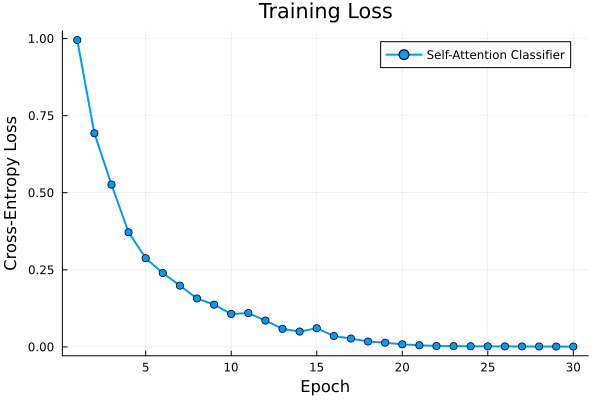

In [12]:
let
    # plot per-epoch training loss to verify convergence
    plot(1:length(train_loss_history), train_loss_history;
         xlabel="Epoch", ylabel="Cross-Entropy Loss",
         label="Self-Attention Classifier",
         title="Training Loss",
         linewidth=2, marker=:circle, markersize=4,
         legend=:topright)
end

___

## Task 3: Evaluate and Compare with Baseline
We compute test accuracy and a confusion matrix to see which classes the self-attention model gets right and where it makes mistakes. Then we train the L10b mean-pool baseline on the same train/test split for an apples-to-apples comparison.

> __Evaluation strategy.__ We compare the self-attention classifier against the L10b mean-pool baseline on the same held-out test set. The baseline takes the mean of GloVe vectors for each review (collapsing the sequence into a single $100$-dimensional vector) and runs it through the same MLP head architecture. By holding the train/test split fixed, the only difference is whether the model sees a single mean vector or the full token sequence.

Let's compute the confusion matrix for the self-attention model.

In [13]:
test_pred, test_true, test_acc, C_attn, cm_labels = let

    # compute predictions on the held-out test set
    test_logits = model(X_test_seq, mask_test);               # (n_classes, n_test) logits
    test_pred = Flux.onecold(test_logits);              # predicted class indices
    test_true = Flux.onecold(y_test);                   # true class indices
    test_acc = mean(test_pred .== test_true);           # test accuracy
    @info "self-attention test accuracy" acc=round(test_acc, digits=4)

    # build and display the confusion matrix (rows = true class, cols = predicted class)
    C_attn = confusion_matrix(test_true, test_pred, N_CLASSES);
    cm_labels = ["true \\ pred"; CLASS_NAMES];
    println("Confusion matrix (rows = true, cols = predicted):");
    rows = [[CLASS_NAMES[i]; C_attn[i, :]] for i in 1:N_CLASSES];
    pretty_table(reduce(vcat, [permutedims(r) for r in rows]); column_labels=cm_labels)

    # return -
    (test_pred, test_true, test_acc, C_attn, cm_labels)
end

┌ Info: self-attention test accuracy
│   acc = 0.96
└ @ Main /Users/jeffreyvarner/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CHEME-5820-Lectures-Spring-2026/lectures/week-13/L13a/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y135sZmlsZQ==.jl:8


Confusion matrix (rows = true, cols = predicted):
┌──────────────┬──────────┬──────────┬─────────┐
│ true \\ pred │ positive │ negative │ neutral │
├──────────────┼──────────┼──────────┼─────────┤
│     positive │       64 │        1 │       2 │
│     negative │        4 │       65 │       0 │
│      neutral │        0 │        1 │      63 │
└──────────────┴──────────┴──────────┴─────────┘


([2, 2, 3, 1, 3, 1, 1, 3, 1, 3  …  2, 1, 1, 1, 3, 2, 1, 2, 2, 2], [2, 2, 3, 1, 3, 1, 1, 3, 2, 3  …  2, 1, 1, 1, 3, 2, 1, 2, 2, 2], 0.96, [64 1 2; 4 65 0; 0 1 63], ["true \\ pred", "positive", "negative", "neutral"])

Now we train the L10b mean-pool baseline on the same train/test indices.

In [14]:
# re-embed reviews as mean-pooled vectors (the L10b bag-of-embeddings path)
X_mean = embed_reviews(string.(reviews_df.review), glove; dim=D_EMB); # (d, N) matrix
X_train_mean = X_mean[:, TRAIN_IDX];  # training set mean-pooled embeddings
X_test_mean  = X_mean[:, TEST_IDX];   # test set mean-pooled embeddings
@info "mean-pooled embeddings" X_train=size(X_train_mean) X_test=size(X_test_mean)

┌ Info: mean-pooled embeddings
│   X_train = (100, 799)
│   X_test = (100, 200)
└ @ Main /Users/jeffreyvarner/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CHEME-5820-Lectures-Spring-2026/lectures/week-13/L13a/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y140sZmlsZQ==.jl:5


Next, we train the baseline model on the same split and evaluate its test accuracy.

In [15]:
baseline, n_baseline_params, baseline_loss_history, baseline_pred, baseline_acc = let

    # build the L10b baseline: same MLP head architecture, but input is a single mean vector
    Random.seed!(42);
    baseline = Chain(Dense(D_EMB => D_HIDDEN, relu), Dense(D_HIDDEN => N_CLASSES));
    n_baseline_params = sum(length, Flux.trainables(baseline));
    @info "L10b mean-pool baseline" n_params=n_baseline_params

    # train with Adam for the same number of epochs and batch size as the self-attention model
    n_epochs = 30;
    batchsize = 32;
    opt_b = Flux.setup(Adam(3.0f-3), baseline);
    baseline_loss_history = Float32[];
    n_tr = size(X_train_mean, 2);

    for epoch in 1:n_epochs
        epoch_losses = Float32[];
        perm_e = randperm(n_tr); # shuffle each epoch
        for i in 1:batchsize:n_tr
            idxs = perm_e[i:min(i + batchsize - 1, n_tr)];
            Xb = X_train_mean[:, idxs];  # batch of mean-pooled vectors
            yb = y_train[:, idxs];        # batch of one-hot labels
            l, gs = Flux.withgradient(baseline) do m
                Flux.logitcrossentropy(m(Xb), yb)
            end
            push!(epoch_losses, l);
            Flux.update!(opt_b, baseline, gs[1]);
        end
        push!(baseline_loss_history, mean(epoch_losses));
    end

    # evaluate baseline on the same test set
    baseline_pred = Flux.onecold(baseline(X_test_mean)); # predicted class indices
    baseline_acc = mean(baseline_pred .== test_true);     # test accuracy
    @info "L10b baseline test accuracy" acc=round(baseline_acc, digits=4)

    # display baseline confusion matrix
    C_base = confusion_matrix(test_true, baseline_pred, N_CLASSES);
    println("Baseline confusion matrix (rows = true, cols = predicted):");
    rows_b = [[CLASS_NAMES[i]; C_base[i, :]] for i in 1:N_CLASSES];
    pretty_table(reduce(vcat, [permutedims(r) for r in rows_b]); column_labels=cm_labels)

    # return -
    (baseline, n_baseline_params, baseline_loss_history, baseline_pred, baseline_acc)
end

┌ Info: L10b mean-pool baseline
│   n_params = 6659
└ @ Main /Users/jeffreyvarner/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CHEME-5820-Lectures-Spring-2026/lectures/week-13/L13a/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y142sZmlsZQ==.jl:7
┌ Info: L10b baseline test accuracy
│   acc = 0.905
└ @ Main /Users/jeffreyvarner/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CHEME-5820-Lectures-Spring-2026/lectures/week-13/L13a/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y142sZmlsZQ==.jl:35


Baseline confusion matrix (rows = true, cols = predicted):
┌──────────────┬──────────┬──────────┬─────────┐
│ true \\ pred │ positive │ negative │ neutral │
├──────────────┼──────────┼──────────┼─────────┤
│     positive │       64 │        0 │       3 │
│     negative │        4 │       57 │       8 │
│      neutral │        0 │        4 │      60 │
└──────────────┴──────────┴──────────┴─────────┘


(Chain(Dense(100 => 64, relu), Dense(64 => 3)), 6659, Float32[1.0360228, 0.90004575, 0.791116, 0.68737215, 0.61456865, 0.557776, 0.5112015, 0.46540597, 0.45328373, 0.4163194  …  0.2585051, 0.2534556, 0.24470995, 0.23255138, 0.22130066, 0.21700394, 0.20971163, 0.20970789, 0.19267361, 0.19102898], [2, 2, 3, 1, 3, 1, 1, 3, 1, 3  …  2, 1, 1, 1, 3, 2, 1, 2, 2, 2], 0.905)

Let's compare the two architectures side by side.

In [16]:
let
    # side-by-side comparison of the two architectures
    comparison = DataFrame(
        architecture = ["L10b mean-pool baseline", "Single-head self-attention"],
        n_params = [n_baseline_params, n_params],
        test_accuracy = [round(baseline_acc, digits=4), round(test_acc, digits=4)],
    );
    pretty_table(comparison)
end

┌────────────────────────────┬──────────┬───────────────┐
│               architecture │ n_params │ test_accuracy │
│                     String │    Int64 │       Float64 │
├────────────────────────────┼──────────┼───────────────┤
│    L10b mean-pool baseline │     6659 │         0.905 │
│ Single-head self-attention │    11907 │          0.96 │
└────────────────────────────┴──────────┴───────────────┘


### Visualizing attention weights on adversarial examples
Each row of the attention matrix is a probability distribution over the keys, telling us how much that query attends to each key. We pick adversarial test reviews (sarcastic and double-negative) and plot the attention matrix as a heatmap using the `plot_attention(...)` function defined above. The token strings are placed on both axes so we can read off which words the model attends to.

In [17]:
attn_pred_test, base_pred_test, POS_IDX, NEG_IDX, sarc_candidates = let

    # compute both models' predictions on the test set
    attn_pred_test = Flux.onecold(model(X_test_seq, mask_test));  # self-attention predictions
    base_pred_test = Flux.onecold(baseline(X_test_mean));          # baseline predictions
    pos_idx = label_to_idx["positive"];
    neg_idx = label_to_idx["negative"];

    # find sarcastic reviews where self-attention is correct but baseline fails.
    # require both positive vocabulary AND an obvious sarcastic cue so the
    # displayed example reads as genuinely sarcastic (not stealth-positive).
    POS_VOCAB = r"(amazing|fantastic|wonderful|love|incredible|delicious|smooth|perfect|outstanding|brilliant|best|favorite|deligh|impress|treasure)"i
    SARC_CUE  = r"(disappoint|battery acid|burnt|watery|terrible|zero energy|bad|headache|ineffective|cheap|mediocre|regret|nonexistent|hates|worst enemy|dislike|never buying|sink|down the)"i

    sarc_candidates = findall(i ->
        test_true[i] == neg_idx &&              # true label is negative
        attn_pred_test[i] == neg_idx &&          # self-attention predicts negative (correct)
        base_pred_test[i] != neg_idx &&          # baseline predicts something else (wrong)
        occursin(POS_VOCAB, reviews_df.review[TEST_IDX[i]]) &&  # review contains positive vocabulary
        occursin(SARC_CUE, reviews_df.review[TEST_IDX[i]]),     # review contains a sarcastic cue
        1:length(test_true));

    @info "sarcastic wins" n=length(sarc_candidates)

    # print the first sarcastic example where self-attention wins
    if !isempty(sarc_candidates)
        si = sarc_candidates[1];
        println();
        println("Sarcastic test review (true label: negative)");
        println(reviews_df.review[TEST_IDX[si]]);
        println();
        println("self-attention predicts: ", CLASS_NAMES[attn_pred_test[si]], "  (correct)");
        println("L10b baseline predicts:  ", CLASS_NAMES[base_pred_test[si]], "  (wrong)");
    end

    # return -
    (attn_pred_test, base_pred_test, pos_idx, neg_idx, sarc_candidates)
end

┌ Info: sarcastic wins
│   n = 1
└ @ Main /Users/jeffreyvarner/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CHEME-5820-Lectures-Spring-2026/lectures/week-13/L13a/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y146sZmlsZQ==.jl:23



Sarcastic test review (true label: negative)
QuantumBrew is the best thing that happened to my mornings this year. The energy from the Classic Espresso Surge is steady, smooth, and lasts all day long. I would recommend this to my worst enemy.

self-attention predicts: negative  (correct)
L10b baseline predicts:  neutral  (wrong)


([2, 2, 3, 1, 3, 1, 1, 3, 1, 3  …  2, 1, 1, 1, 3, 2, 1, 2, 2, 2], [2, 2, 3, 1, 3, 1, 1, 3, 1, 3  …  2, 1, 1, 1, 3, 2, 1, 2, 2, 2], 1, 2, [153])

Let's plot the attention heatmap for the first sarcastic review found above.

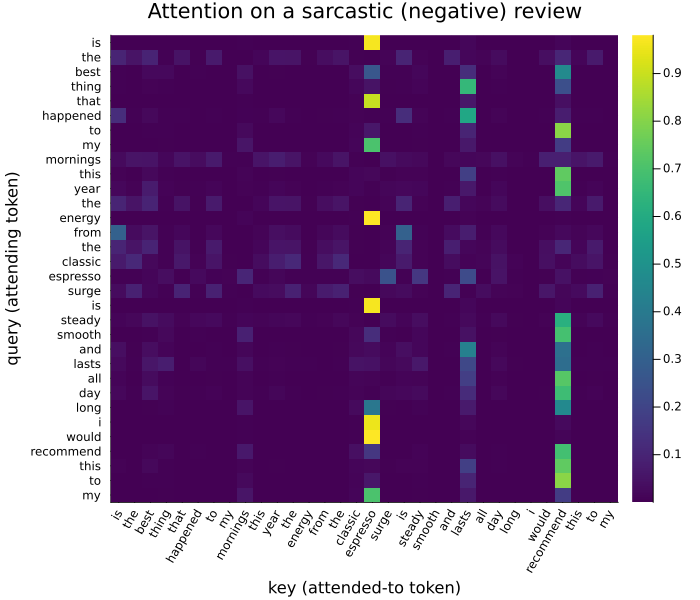

In [18]:
let
    # plot the attention heatmap for the first sarcastic review
    si = sarc_candidates[1];
    plot_attention(model,
                   X_test_seq[:, :, si:si],        # single review token sequence (d, n_max, 1)
                   mask_test[:, si:si],             # single review mask (n_max, 1)
                   tokens_str[:, TEST_IDX[si]];     # token strings for axis labels
                   title_str="Attention on a sarcastic (negative) review")
end

Next, we look for double-negative reviews where self-attention classifies correctly but the baseline fails.

In [19]:
dn_candidates = let

    # find double-negative reviews where self-attention is correct but baseline fails.
    # these reviews use heavy negation vocabulary but are labeled positive.
    dn_candidates = findall(i ->
        test_true[i] == POS_IDX &&               # true label is positive
        attn_pred_test[i] == POS_IDX &&           # self-attention predicts positive (correct)
        base_pred_test[i] != POS_IDX &&           # baseline predicts something else (wrong)
        _negation_count(reviews_df.review[TEST_IDX[i]]) >= 3,  # review has 3+ negation tokens
        1:length(test_true));

    @info "heavy-negation wins" n=length(dn_candidates)

    # print the first double-negative example where self-attention wins
    if !isempty(dn_candidates)
        di = dn_candidates[1];
        println();
        println("Double-negative test review (true label: positive)");
        println(reviews_df.review[TEST_IDX[di]]);
        println();
        println("self-attention predicts: ", CLASS_NAMES[attn_pred_test[di]], "  (correct)");
        println("L10b baseline predicts:  ", CLASS_NAMES[base_pred_test[di]], "  (wrong)");
    end

    # return -
    dn_candidates
end


Double-negative test review (true label: positive)
QuantumBrew is not awful, not mediocre, not even just acceptable, it is great. I was bracing for a terrible aftertaste from the Caramel Thunder but there was none. Not buying this would be the worst mistake a coffee lover could make.

self-attention predicts: positive  (correct)
L10b baseline predicts:  neutral  (wrong)


┌ Info: heavy-negation wins
│   n = 2
└ @ Main /Users/jeffreyvarner/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CHEME-5820-Lectures-Spring-2026/lectures/week-13/L13a/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y153sZmlsZQ==.jl:12


2-element Vector{Int64}:
 131
 174

Let's visualize the attention pattern on the first double-negative review.

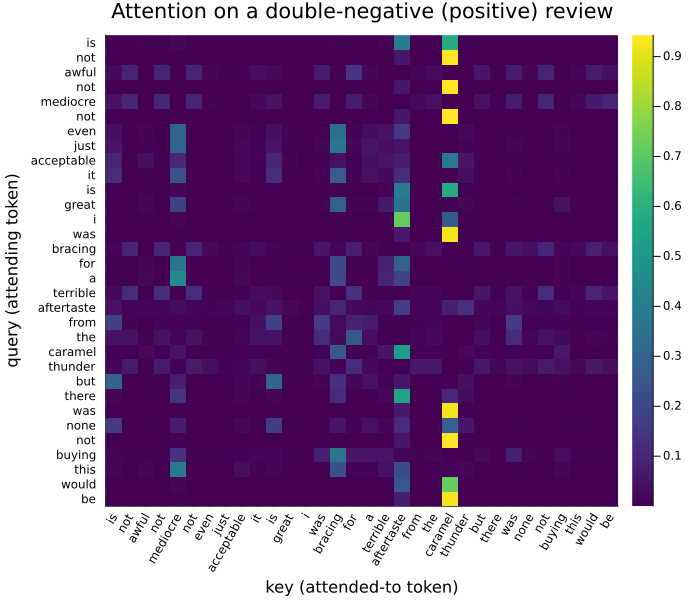

In [20]:
let
    # plot the attention heatmap for the first double-negative review
    di = dn_candidates[1];
    plot_attention(model,
                   X_test_seq[:, :, di:di],        # single review token sequence (d, n_max, 1)
                   mask_test[:, di:di],             # single review mask (n_max, 1)
                   tokens_str[:, TEST_IDX[di]];     # token strings for axis labels
                   title_str="Attention on a double-negative (positive) review")
end

### Things to think about
The attention heatmaps above let you see _which tokens the model is looking at_ when it makes its prediction. A few questions to think through:

* __What is the structure of a "typical" attention pattern?__ For most queries, where does the attention concentrate? Are there a few "hub" tokens that many queries attend to, or does each query distribute its attention more evenly?
* __How does attention behave on the sarcastic review?__ The L10b mean-pool baseline averages all word vectors with equal weight, so a sarcastic review with positive vocabulary looks positive. Does the self-attention model learn to discount the positive vocabulary, and which tokens does it attend to instead?
* __How does attention handle negation?__ In the double-negative review, the words "not", "never", and "no" appear several times. Does the attention layer concentrate on these negation words, or does it route around them?
* __When does the self-attention model still make mistakes?__ Look at the confusion matrices for both the baseline and the self-attention model. Which class is each model worst at? Does self-attention fix the same mistakes the baseline makes, or does it trade one set of mistakes for another?
* __What is the parameter count buying us?__ The self-attention model has more parameters than the baseline. How much of the accuracy gap is explained by extra capacity, and how much by the architectural change of being able to look at individual tokens instead of a single pooled vector? You could test this by training the baseline with a wider hidden dimension to roughly match the self-attention parameter count.

## Summary
We trained a single-head self-attention classifier on the same QuantumBrew sentiment dataset as the L10b lab and compared it against the L10b mean-pool baseline on the same train/test split.

> __Key Takeaways__:
>
> * __Self-attention operates on token sequences, not pooled vectors__: Replacing mean-pooling with self-attention required re-embedding each review as a padded sequence of GloVe vectors and adding a key-padding mask so attention does not attend to padding positions.
> * __The same dataset, the same split, two architectures__: Holding the train/test split fixed and using the same MLP head and optimizer makes the comparison apples-to-apples. The only change is whether the model sees a single mean vector or the full token sequence.
> * __Attention weights are an interpretation tool__: Plotting the attention matrix on adversarial reviews shows which tokens the trained model attends to, providing a window into why the model made a particular prediction.

These results show how a sequence-aware attention mechanism can capture token-level interactions that a mean-pool baseline discards.
___